## Car Market Trend Analysis 

In [121]:
# Import Library 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date 

## Data Load and Exploration 

In [122]:
# Data Load
df = pd.read_csv('Car_Market_Trends_Analysis_with_Car_Dekho_Data.csv')
print(f"""Dataset Column and records count : 
        {df.count()}""")

Dataset Column and records count : 
        Car_Name         301
Year             301
Selling_Price    301
Present_Price    301
Kms_Driven       301
Fuel_Type        301
Seller_Type      301
Transmission     301
Owner            301
dtype: int64


In [123]:
# Dataset Structure
print(f"""Dataset Structure : {df.shape}""")

Dataset Structure : (301, 9)


In [124]:
#df.head() # top 5 rows
df.tail(10) # bottom 5 rows

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
291,brio,2015,5.40,6.10,31427,Petrol,Dealer,Manual,0
292,jazz,2016,6.40,8.40,12000,Petrol,Dealer,Manual,0
293,city,2010,3.25,9.90,38000,Petrol,Dealer,Manual,0
294,amaze,2014,3.75,6.80,33019,Petrol,Dealer,Manual,0
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.90,5464,Petrol,Dealer,Manual,0


In [125]:
# Check datatype and Null value count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [126]:
# Descriptive Summary 
df.describe()




,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [127]:
# Data Quality Check 

#1. Duplicate Value -  2 duplicate values found 
duplicate_count = df.duplicated().sum() #
print(f'Duplicate count : {duplicate_count}')
df.drop_duplicates(inplace=True)

Duplicate count : 2


In [128]:
#2. Null Value - No null value found

missing_value = pd.DataFrame({
    'Missing Count' : df.isna().sum(),
    'Missing Pct' : (df.isna().mean()*100).round(2)
})
print(missing_value)

               Missing Count  Missing Pct
Car_Name                   0          0.0
Year                       0          0.0
Selling_Price              0          0.0
Present_Price              0          0.0
Kms_Driven                 0          0.0
Fuel_Type                  0          0.0
Seller_Type                0          0.0
Transmission               0          0.0
Owner                      0          0.0


## Data Analysis  

In [129]:
# Before Performing analysis we are making copy of orignal data ,so during  analysis it  doesn't affect original data
df_copy = df.copy()

df_copy




,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [130]:
# Feature Engineering 
# 1. Car Age
current_year = date.today().year
df_copy["Car_Age"] = current_year - df_copy["Year"] 

# 2. Car Value Depreciation 
df_copy['Depreciation_Amount'] = df_copy['Present_Price'] - df_copy['Selling_Price']
df_copy['Depreciation_Pct'] = (df_copy['Depreciation_Amount'] / df_copy['Selling_Price'] * 100).round(2)
df_copy

# 3. Mileage Bucket 
mileage_labels = ['0-25k', '25k-50k', '50k-75k', '75k-100k', '100k+']
mileage_bins = [0, 25000, 50000, 75000, 100000, np.inf]
df_copy['Mileage_Bucket'] = pd.cut(df_copy['Kms_Driven'], bins=mileage_bins, labels=mileage_labels)

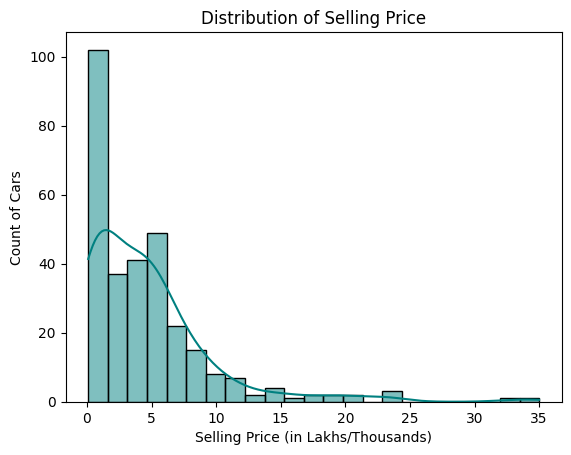

In [131]:
# Selling Price Distribution 
sns.histplot(df_copy["Selling_Price"], kde=True, color="teal")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (in Lakhs/Thousands)")
plt.ylabel("Count of Cars")
plt.savefig("price_distribution.jpg")
plt.show()


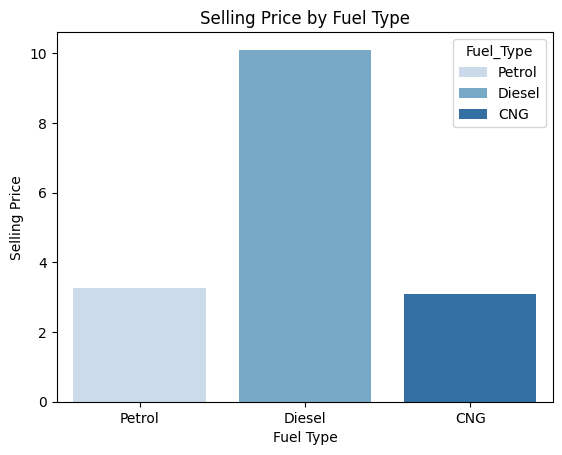

In [132]:
# Fuel Type vs Selling Price
sns.barplot(x="Fuel_Type", y="Selling_Price", data=df_copy,hue='Fuel_Type', errorbar=None, palette="Blues",legend=True)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.savefig("price_fueltype.jpg")
plt.show()


In [133]:
# Outliers : Instead of removing records i would fill with null value to avoid data loss 
Q1 = df_copy['Selling_Price'].quantile(0.25)
Q3 = df_copy['Selling_Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[
    (df_copy['Selling_Price'] < lower) | (df_copy['Selling_Price'] > upper),
    'Selling_Price'
] = np.nan

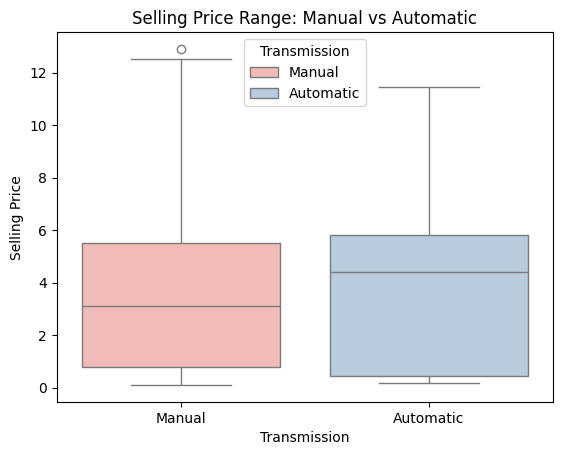

In [134]:
# Transmission vs Selling Price
sns.boxplot(x="Transmission", y="Selling_Price", data=df_copy,hue='Transmission', palette="Pastel1", legend=True)
plt.title("Selling Price Range: Manual vs Automatic")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.savefig("price_transmission.jpg")
plt.show()


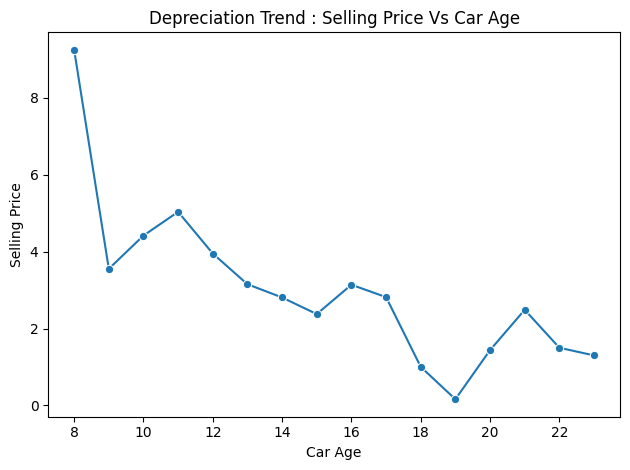

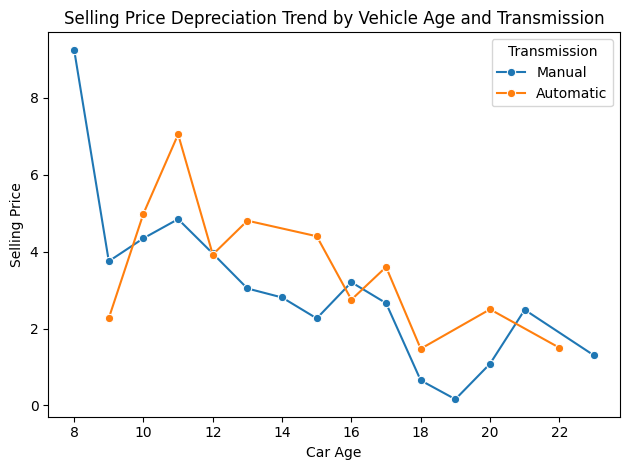

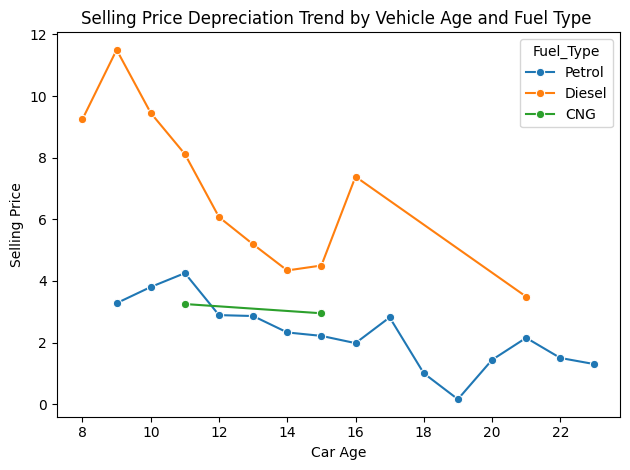

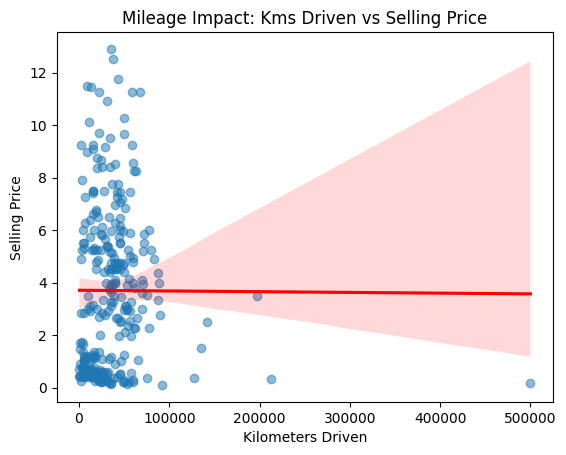

In [135]:
# Car Age vs Depreciation (Depreciation Trend)
# 1.
sns.lineplot(data=df_copy, x="Car_Age", y="Selling_Price", marker="o", errorbar=None)
plt.title("Depreciation Trend : Selling Price Vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("price_depreicaitontrend.jpg")
plt.show()

# 2.
sns.lineplot(data=df_copy, x="Car_Age", y="Selling_Price", hue="Transmission", marker="o", errorbar=None)
plt.title("Selling Price Depreciation Trend by Vehicle Age and Transmission")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

# 3.
sns.lineplot(data=df_copy, x="Car_Age", y="Selling_Price", hue="Fuel_Type", marker="o", errorbar=None)
plt.title("Selling Price Depreciation Trend by Vehicle Age and Fuel Type ")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

# 3.
sns.regplot(data=df_copy, x="Kms_Driven", y="Selling_Price", # robust=True,  # Ignores the outlier's leverage when drawing the line
    #ci=None,  # Speed up calculation by turning off confidence interval
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Mileage Impact: Kms Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
#plt.xlim(-5000, 150000)
plt.savefig("price_mileageimpact.jpg")
plt.show()


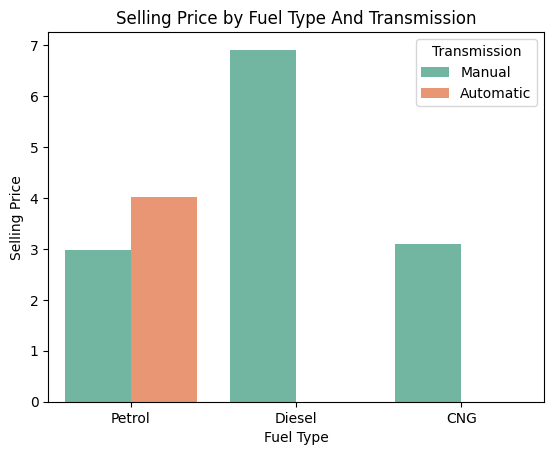

In [136]:
# Fuel & Transmission Preference Shifts
sns.barplot(data=df_copy,x='Fuel_Type',y="Selling_Price",hue="Transmission",errorbar=None, palette="Set2")
plt.title("Selling Price by Fuel Type And Transmission")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

Owner
0    288
1     10
3      1
Name: count, dtype: int64
Owner
0    96.321070
1     3.344482
3     0.334448
Name: proportion, dtype: float64


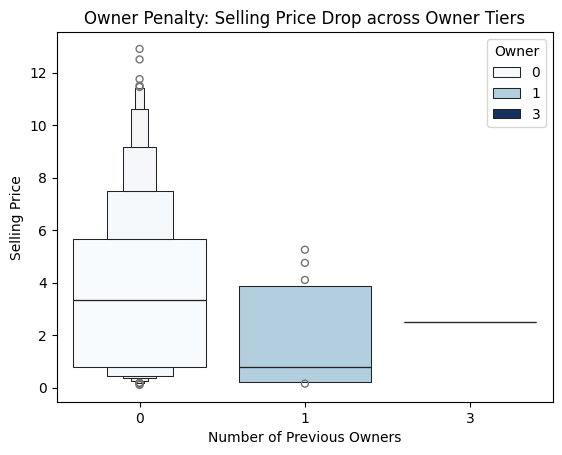

In [137]:
# Owner Penalty 
# Check how many cars are in each owner category
print(df_copy["Owner"].value_counts())
print(df_copy["Owner"].value_counts(normalize=True)*100)
sns.boxenplot(data=df_copy,x="Owner",y="Selling_Price",hue = "Owner", palette="Blues")
plt.title("Owner Penalty: Selling Price Drop across Owner Tiers")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Selling Price")
plt.savefig("price_ownerpenalty.jpg")
plt.show()


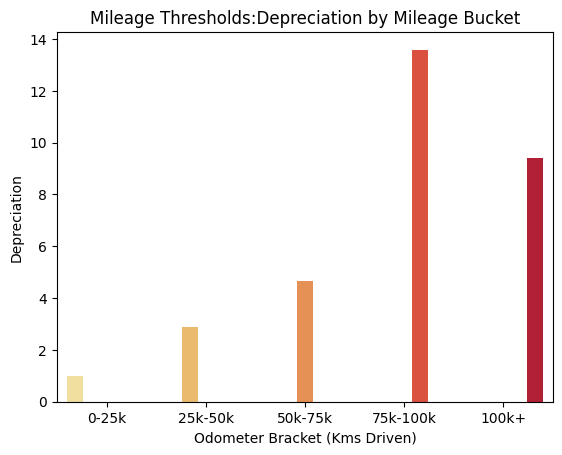

In [138]:
# Odometer Milestones 
sns.barplot(data=df_copy, x="Mileage_Bucket", y="Depreciation_Amount", hue="Mileage_Bucket", errorbar=None, palette="YlOrRd")
plt.title("Mileage Thresholds:Depreciation by Mileage Bucket")
plt.xlabel("Odometer Bracket (Kms Driven)")
plt.ylabel("Depreciation")
plt.savefig("price_mileagebucket.jpg")
plt.show()



              min  median   max  count
Seller_Type                           
Dealer       1.05   4.975  12.9    178
Individual   0.10   0.510   6.0    105


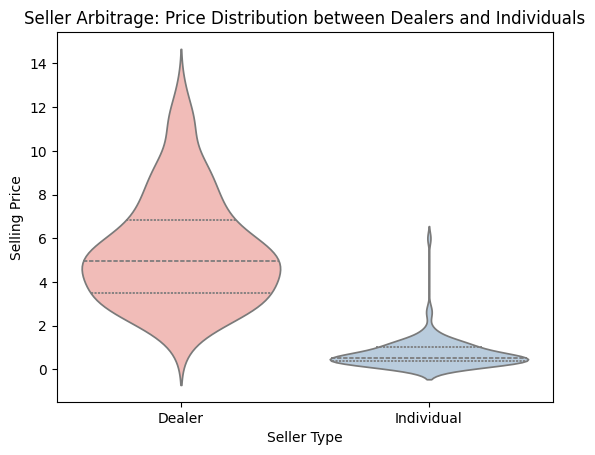

In [139]:
# Dealer vs Individual Pricing Spread
# Calculate key price statistics for each Seller Type
seller_stats = df_copy.groupby("Seller_Type")["Selling_Price"].agg(
    ["min", "median", "max", "count"]
)
print(seller_stats)

sns.violinplot(data=df_copy, x="Seller_Type", y="Selling_Price", hue="Seller_Type", palette="Pastel1", inner="quartile")
plt.title("Seller Arbitrage: Price Distribution between Dealers and Individuals")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.savefig("price_seller.jpg")
plt.show()


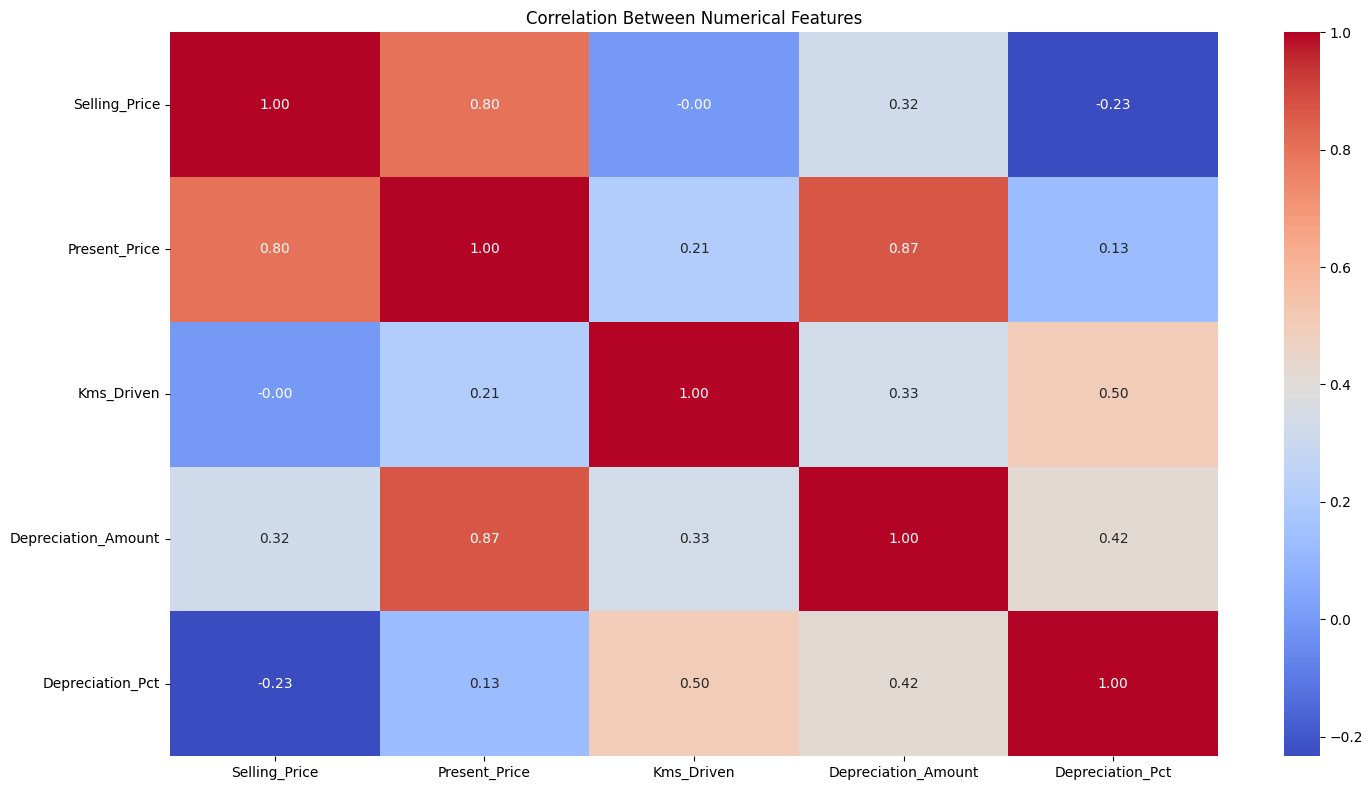

In [141]:
# Correlation Heatmap To check relationship between different columns 
plt.figure(figsize=(15,8))
numerical_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Depreciation_Amount", "Depreciation_Pct"]
sns.heatmap(df_copy[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.savefig("heatmap.jpg")
plt.tight_layout()
plt.show()


## Analysis Completed
